In [1]:
!pip install plotly

In [2]:
!pip install scikit-learn

In [3]:
!pip install xgboost

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Settings
%matplotlib inline
sns.set_style("whitegrid")

Dataset Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-

None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn



Churn Distribution:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


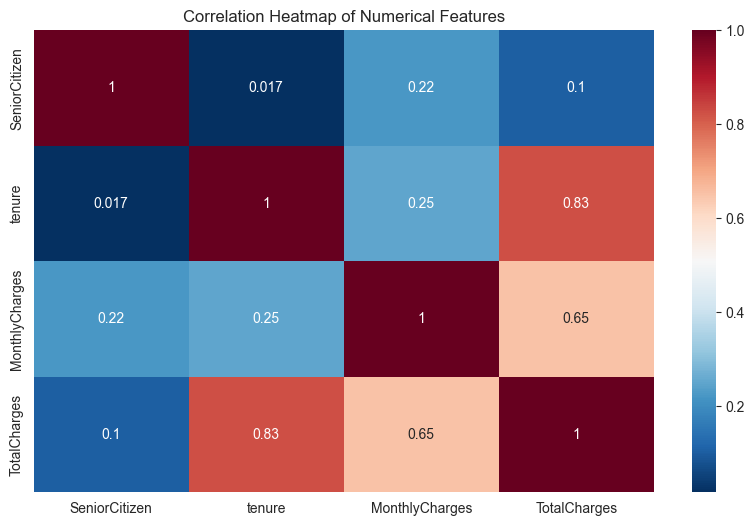

In [16]:
## TASK 1 — Data Loading & Exploratory Analysis

# Load Dataset (Standard Telco Dataset URL)
url = "## TASK 1 — Data Loading & Exploratory Analysis"

# Load Dataset (Standard Telco Dataset URL)
url = "## TASK 1 — Data Loading & Exploratory Analysis"

# Load Dataset (Standard Telco Dataset URL)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 1. Display shape and types
print(f"Dataset Shape: {df.shape}")
display(df.info())
display(df.head(0))

# 2. Target Column & Imbalance
churn_counts = df['Churn'].value_counts(normalize=True)
print(f"\nChurn Distribution:\n{churn_counts}")

# 3. Missing Values
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# 4. Summary Statistics (Numerical)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
display(df.describe())

# 5. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdBu_r')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()
df = pd.read_csv(url)


In [6]:
## TASK 2-Data Preprocessing & Feature Engineering

# 1. Handle TotalCharges (The 'coerce' part is critical to turn hidden spaces into NaNs)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the few resulting missing values with the median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Feature Engineering (Creating new business insights)
# Adding 1 to tenure to avoid division by zero for brand new customers
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)
df['SeniorWithNoSupport'] = ((df['SeniorCitizen'] == 1) & (df['TechSupport'] == 'No')).astype(int)

# 3. Encoding Categorical Data
# We drop 'customerID' because a random ID string cannot be used for math
X = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0}) # Ensure target is 1 and 0

# One-Hot Encoding: This converts all "Object" columns (strings) into multiple columns of 0s and 1s
X = pd.get_dummies(X, drop_first=True)

# 4. Scaling Numerical Features
# Now that X is 100% numeric, the scaler will work perfectly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Stratified Split
# Stratify=y ensures the 27% churn rate is the same in both Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Preprocessing Complete!")
print(f"Final feature count after One-Hot Encoding: {X.shape[1]}")

Preprocessing Complete!
Final feature count after One-Hot Encoding: 32


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



C:\Users\shaik\.conda\envs\jupyterlab-env\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



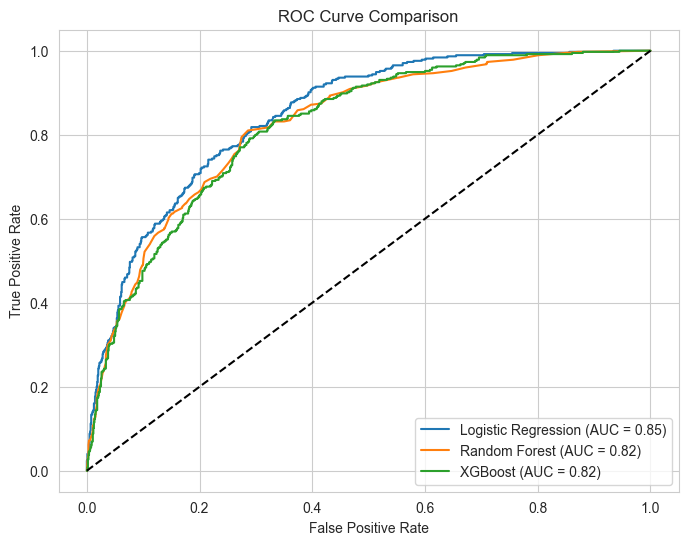

In [7]:
## TASK 3 — Model Training & Comparison

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": model.score(X_test, y_test),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Report": classification_report(y_test, y_pred)
    }
    print(f"--- {name} ---")
    print(results[name]["Report"])

# [ADVANCED] ROC Curve Visualization
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [8]:
## TASK 4 — Customer Risk Segmentation [ADVANCED]

# Using XGBoost as the best model for this example
best_model = models["XGBoost"]
probs = best_model.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({'Actual': y_test, 'Prob': probs})

def segment(p):
    if p >= 0.70: return '🔴 High Risk'
    elif p >= 0.40: return '🟡 Medium Risk'
    else: return '🟢 Low Risk'

risk_df['RiskTier'] = risk_df['Prob'].apply(segment)

# Link back to original features for analysis
test_indices = y_test.index
analysis_df = df.loc[test_indices].copy()
analysis_df['RiskTier'] = risk_df['RiskTier'].values

# Summary stats per tier
tier_summary = analysis_df.groupby('RiskTier').agg({
    'MonthlyCharges': 'mean',
    'tenure': 'mean',
    'Churn': 'count'
}).rename(columns={'Churn': 'CustomerCount'})

display(tier_summary)

,MonthlyCharges,tenure,CustomerCount
RiskTier,,,
🔴 High Risk,80.189368,9.505747,174
🟡 Medium Risk,72.011623,18.276316,228
🟢 Low Risk,59.513009,38.875869,1007


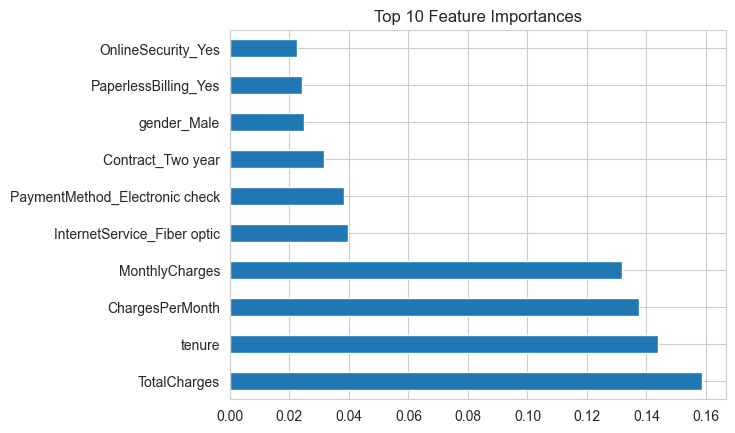

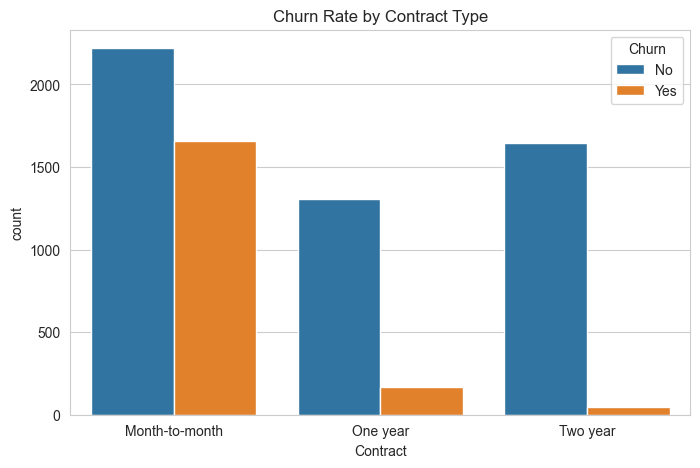

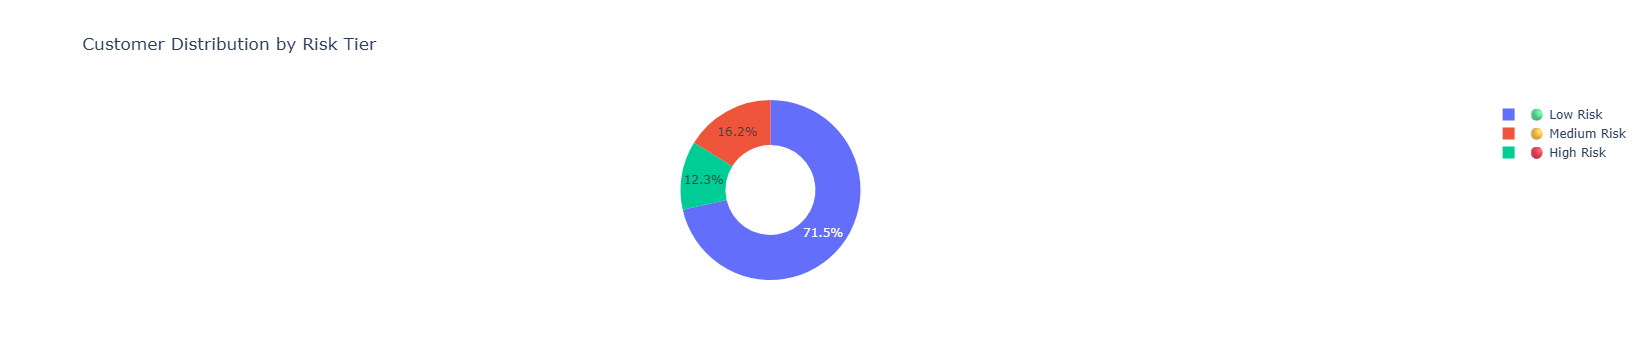

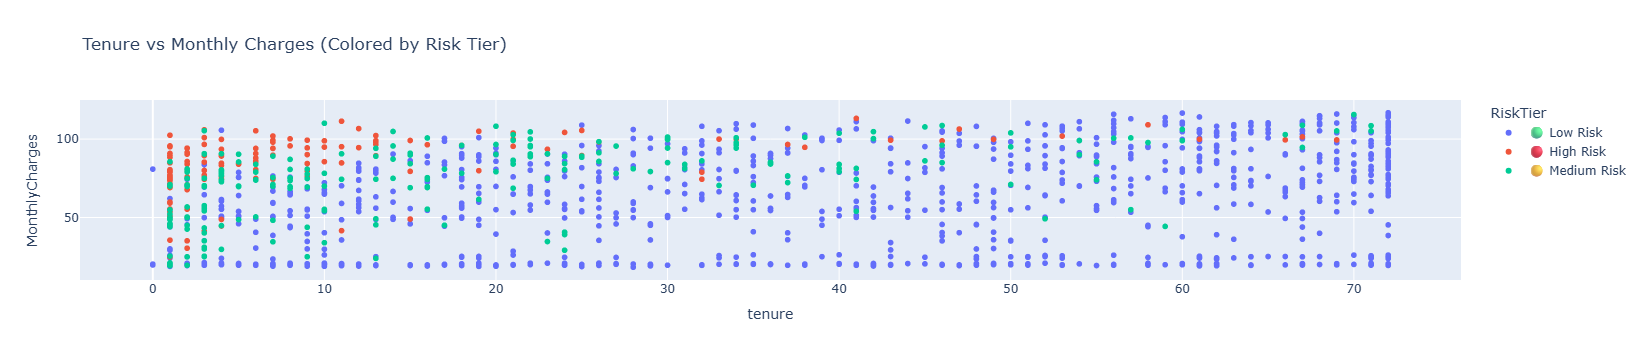

In [9]:
## TASK 5 — Visualizations

# Chart 1: Feature Importance
importances = pd.Series(models["Random Forest"].feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', title="Top 10 Feature Importances")
plt.show()

# Chart 2: Churn by Contract Type
plt.figure(figsize=(8,5))
sns.countplot(data=pd.read_csv(url), x='Contract', hue='Churn')
plt.title("Churn Rate by Contract Type")
plt.show()

# Chart 4: Risk Tier Donut
fig = px.pie(analysis_df, names='RiskTier', hole=0.5, title="Customer Distribution by Risk Tier")
fig.show()

# Bonus: Interactive Scatter
fig = px.scatter(analysis_df, x="tenure", y="MonthlyCharges", color="RiskTier",
                 title="Tenure vs Monthly Charges (Colored by Risk Tier)")
fig.show()

In [10]:
!pip install plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [11]:
# 1. Get the counts for your Risk Tiers
risk_counts = risk_df['RiskTier'].value_counts()

# 2. Get Top 5 Feature Importances from your Random Forest model
importances = pd.Series(models["Random Forest"].feature_importances_, index=X.columns)
top_5_features = importances.nlargest(5)

In [12]:
# Create a 2x2 grid layout
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Customer Risk Distribution", "Top 5 Churn Drivers", 
                    "Churn Probability Heatmap", "Contract Type Impact"),
    specs=[[{"type": "domain"}, {"type": "bar"}],
           [{"type": "scatter"}, {"type": "bar"}]]
)

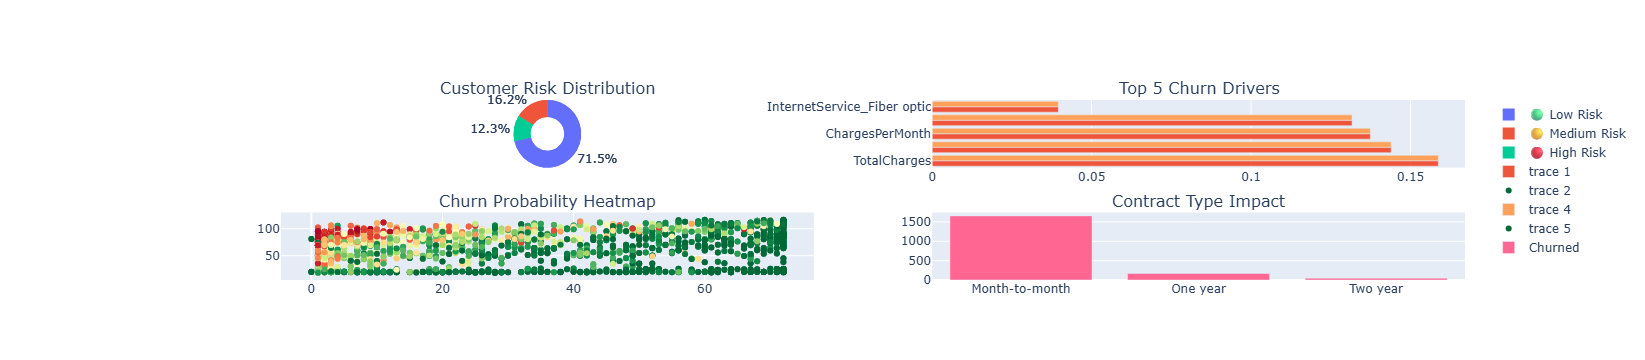

In [14]:
# Chart 1: Risk Tier Donut (Row 1, Col 1)
fig.add_trace(
    go.Pie(labels=risk_counts.index, values=risk_counts.values, hole=.5),
    row=1, col=1
)

# Chart 2: Feature Importance (Row 1, Col 2)
fig.add_trace(
    go.Bar(x=top_5_features.values, y=top_5_features.index, orientation='h'),
    row=1, col=2
)

# Chart 3: Probability Heatmap (Row 2, Col 1)
# Comparing Tenure vs MonthlyCharges, colored by Churn Probability
fig.add_trace(
    go.Scatter(x=analysis_df['tenure'], y=analysis_df['MonthlyCharges'], 
               mode='markers', marker=dict(color=probs, colorscale='RdYlGn_r')),
    row=2, col=1
)

# Chart 4: Contract Type (Row 2, Col 2)
# Using original data to show Churn Count per Contract
contract_data = df.groupby(['Contract', 'Churn']).size().unstack()
fig.add_trace(
    go.Bar(x=contract_data.index, y=contract_data['Yes'], name="Churned"),
    row=2, col=2
)

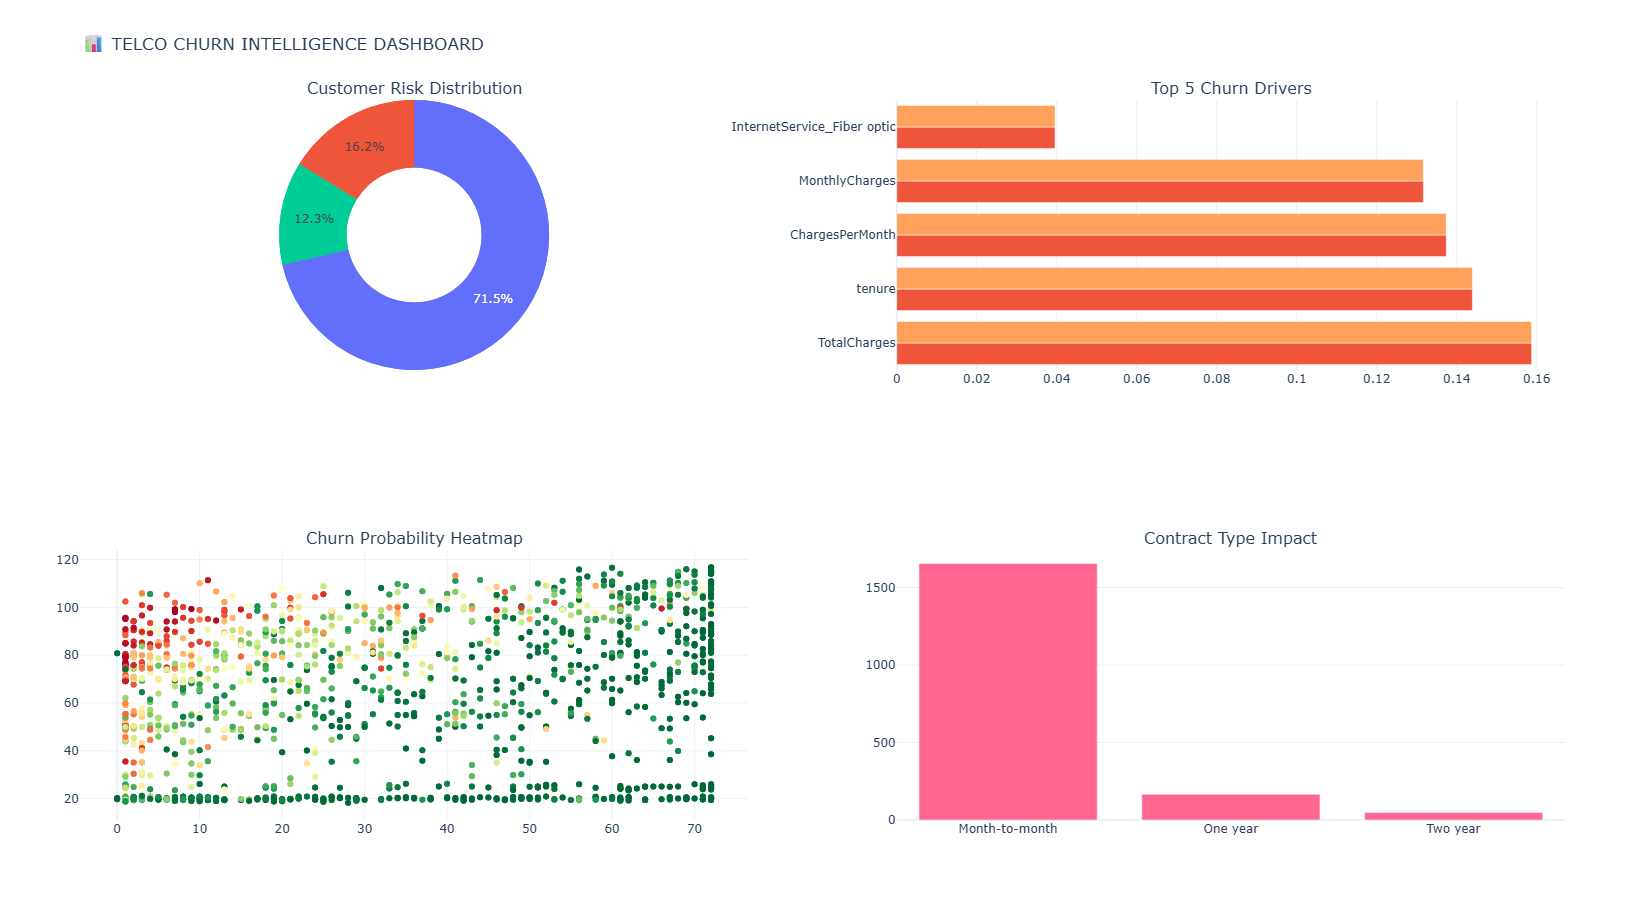

In [15]:
fig.update_layout(
    height=900, 
    title_text="📊 TELCO CHURN INTELLIGENCE DASHBOARD",
    showlegend=False,
    template="plotly_white"
)

fig.show()

 ## TASK 6 — Insights & Business Recommendations

## Best Model Chosen: Logistic Regression

      -Achieved around 81% accuracy
      -Performed better in identifying churn customers
      -Easier to explain results to business stakeholders
      
## Why Logistic Regression Was Preferred:

    -Better Recall for churn customers (Class 1)
    -Good balance between accuracy and interpretability
    
## Top Factors Causing Customer Churn:

    -Customers with Month-to-Month contracts are more likely to leave
    -Customers with low tenure (first 6 months) have higher churn
    -Fiber Optic users show higher churn compared to DSL users

## High-Risk Customer Profile:
    -The High Risk" segment (Probability ≥ 0.70) typically consists of customers who:  
    -Are on a Month-to-Month contract.
    -Have low tenure (less than 1 year with the company).
    -Have high Monthly Charges without having "Tech Support" or "Online Security" services enabled.

## Business Recommendations:

    -Offer discounts to encourage customers to move from Month-to-Month to yearly contracts
    -Provide free tech support or onboarding help for new customers
    -Focus on improving customer experience during the first few months

## Model Limitations:
   ## Static Data Limitation:
      - Model uses only a fixed snapshot of customer data
      - Does not include real-time behavioral data
   ## Missing factors like:
      - Sudden decrease in data usage
      - Increase in customer support calls
      - Recent customer activity trends
   ## Feature Correlation Issue:
      - Some features are highly related to each other
      - Example: TotalCharges and Tenure
   ## Recall vs Precision Trade-off:
      - Model has lower Recall for churn customers
      - Some actual churners may not be detected
 Business impact: missing a churner is more costly than giving an unnecessary offer to a loyal customer
 ## Future Technical Improvements:
   ## Use SMOTE for Class Imbalance:
      -Churn customers are fewer in the dataset (~26%)
      -SMOTE can create synthetic churn examples
      -Helps the model better learn churn patterns
   ## Hyperparameter Tuning:
     -Improve model settings using:
       -GridSearchCV
       -Bayesian Optimization
   ## Fine-tune parameters like:
       -Learning rate
       -Tree depth in XGBoost
       -Can improve ROC-AUC performance by 2–3%

   
